In [1]:
from google.colab import files

uploaded = files.upload()

Saving d2c churn data package-20260617T151555Z-3-001.zip to d2c churn data package-20260617T151555Z-3-001.zip


In [2]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print(os.listdir("data"))

['d2c churn data package']


In [3]:
import os

os.listdir("data/d2c churn data package")

['customers.csv',
 'web_events_snapshot.csv',
 'churn_labels.csv',
 'DATA_DICTIONARY.md',
 'intervention_history.csv',
 'STUDENT_FACING_PROBLEM_STATEMENT.md',
 'orders.csv',
 'rfm_modeling_snapshot.csv',
 'support_tickets.csv']

In [4]:
import pandas as pd

base_path = "data/d2c churn data package/"

customers = pd.read_csv(base_path + "customers.csv")
orders = pd.read_csv(base_path + "orders.csv")
tickets = pd.read_csv(base_path + "support_tickets.csv")
web = pd.read_csv(base_path + "web_events_snapshot.csv")
campaign = pd.read_csv(base_path + "intervention_history.csv")
churn = pd.read_csv(base_path + "churn_labels.csv")
snapshot = pd.read_csv(base_path + "rfm_modeling_snapshot.csv")

In [5]:
inventory = pd.DataFrame({
    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "web_events",
        "campaign",
        "churn_labels",
        "rfm_snapshot"
    ],
    "Rows": [
        len(customers),
        len(orders),
        len(tickets),
        len(web),
        len(campaign),
        len(churn),
        len(snapshot)
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        tickets.shape[1],
        web.shape[1],
        campaign.shape[1],
        churn.shape[1],
        snapshot.shape[1]
    ]
})

inventory

,Dataset,Rows,Columns
0,customers,2400,9
1,orders,10009,10
2,support_tickets,1921,8
3,web_events,2400,10
4,campaign,2400,5
5,churn_labels,2400,4
6,rfm_snapshot,2400,29


In [6]:
for name, df in {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "campaign": campaign,
    "churn": churn,
    "snapshot": snapshot
}.items():

    print("\n")
    print("="*50)
    print(name.upper())
    print("="*50)

    print(df.columns.tolist())



CUSTOMERS
['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent']


ORDERS
['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating']


TICKETS
['ticket_id', 'customer_id', 'ticket_date', 'issue_type', 'support_channel', 'resolution_hours', 'sentiment_score', 'reopened']


WEB
['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']


CAMPAIGN
['customer_id', 'snapshot_date', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket']


CHURN
['customer_id', 'snapshot_date', 'churn_next_60d', 'split']


SNAPSHOT
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_day

In [7]:
for name, df in {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "campaign": campaign,
    "churn": churn,
    "snapshot": snapshot
}.items():

    print("\n")
    print(name.upper())

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    print(missing.sort_values(ascending=False))



CUSTOMERS
loyalty_tier    1386
skin_type        401
dtype: int64


ORDERS
rating    80
dtype: int64


TICKETS
Series([], dtype: int64)


WEB
Series([], dtype: int64)


CAMPAIGN
Series([], dtype: int64)


CHURN
Series([], dtype: int64)


SNAPSHOT
loyalty_tier    1386
dtype: int64


Observation:
Around 58% of the customers lack a loyalty_tier field.

Business Impact:
It can be biased when it comes to customer segment classification by loyalty status. If it is missing it should be considered as a new category (Unknown) and not excluded.

In [9]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "campaign": campaign,
    "churn": churn,
    "snapshot": snapshot
}

In [10]:
for name, df in datasets.items():

    print(
        f"{name}:",
        df.duplicated().sum()
    )

customers: 0
orders: 0
tickets: 0
web: 0
campaign: 0
churn: 0
snapshot: 0


In [12]:
for name, df in datasets.items():
    print(
        name,
        df.shape
    )

customers (2400, 9)
orders (10009, 10)
tickets (1921, 8)
web (2400, 10)
campaign (2400, 5)
churn (2400, 4)
snapshot (2400, 29)


In [14]:
for name, df in datasets.items():

    print(
        name,
        df["customer_id"].nunique()
    )

customers 2400
orders 2400
tickets 1247
web 2400
campaign 2400
churn 2400
snapshot 2400


In [16]:
print(
    "Orders not in customers:",
    len(
        set(orders.customer_id)
        - set(customers.customer_id)
    )
)

print(
    "Tickets not in customers:",
    len(
        set(tickets.customer_id)
        - set(customers.customer_id)
    )
)

print(
    "Web not in customers:",
    len(
        set(web.customer_id)
        - set(customers.customer_id)
    )
)

print(
    "Campaign not in customers:",
    len(
        set(campaign.customer_id)
        - set(customers.customer_id)
    )
)

print(
    "Churn not in customers:",
    len(
        set(churn.customer_id)
        - set(customers.customer_id)
    )
)

Orders not in customers: 0
Tickets not in customers: 0
Web not in customers: 0
Campaign not in customers: 0
Churn not in customers: 0


All datasets successfully join through customer_id. No orphan records were identified.

## Churn Distribution

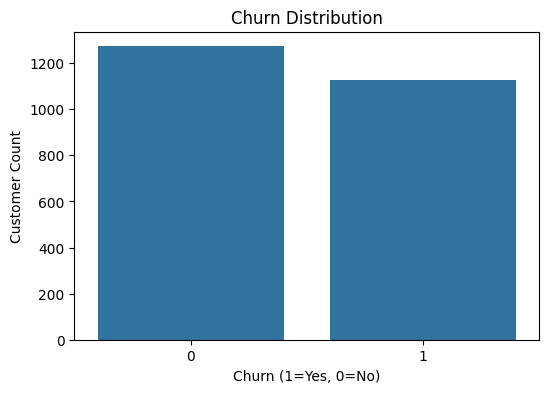

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=churn,
    x="churn_next_60d"
)

plt.title("Churn Distribution")
plt.xlabel("Churn (1=Yes, 0=No)")
plt.ylabel("Customer Count")

plt.show()

print(
    churn["churn_next_60d"]
    .value_counts(normalize=True)*100
)

## Customer Acquisition Analysis

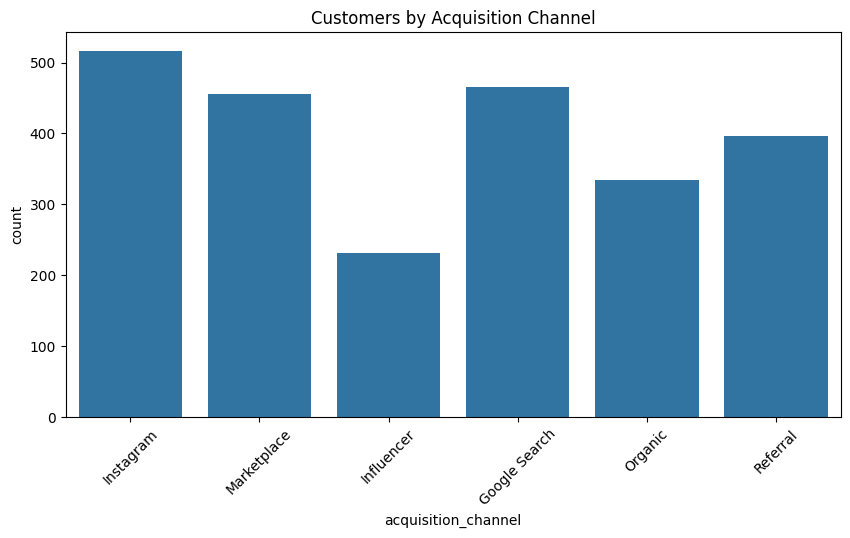

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    x="acquisition_channel"
)

plt.xticks(rotation=45)
plt.title("Customers by Acquisition Channel")

plt.show()

In [19]:
customers["acquisition_channel"].value_counts()

,count
acquisition_channel,
Instagram,517
Google Search,466
Marketplace,456
Referral,396
Organic,334
Influencer,231


##Loyalty Tier Distribution

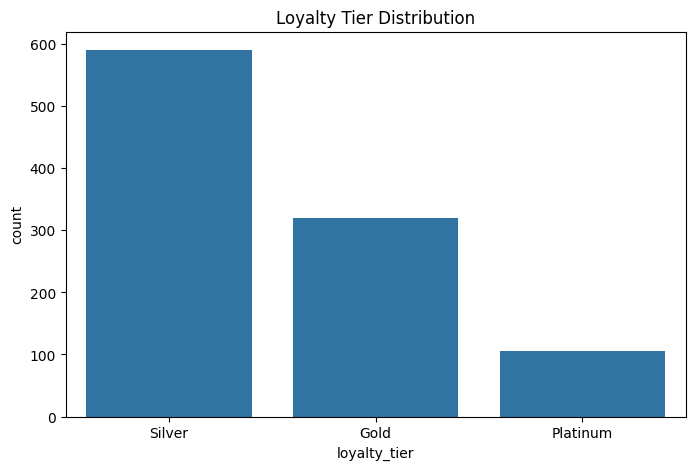

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="loyalty_tier"
)

plt.title("Loyalty Tier Distribution")

plt.show()

Loyalty program enrollment appears incomplete. Missing loyalty information should be treated as a separate customer category rather than discarded.

##Order Revenue Distribution

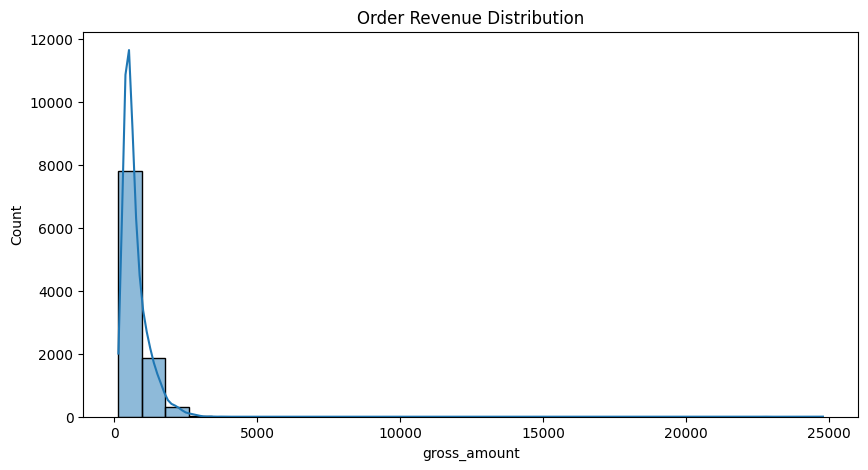

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["gross_amount"],
    bins=30,
    kde=True
)

plt.title("Order Revenue Distribution")

plt.show()

In [22]:
orders["gross_amount"].describe()


,gross_amount
count,10009.000000
mean,743.898504
std,600.564068
min,149.000000
25%,432.850000
50%,597.060000
75%,907.430000
max,24789.380000


##Monthly Orders Trend

In [23]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

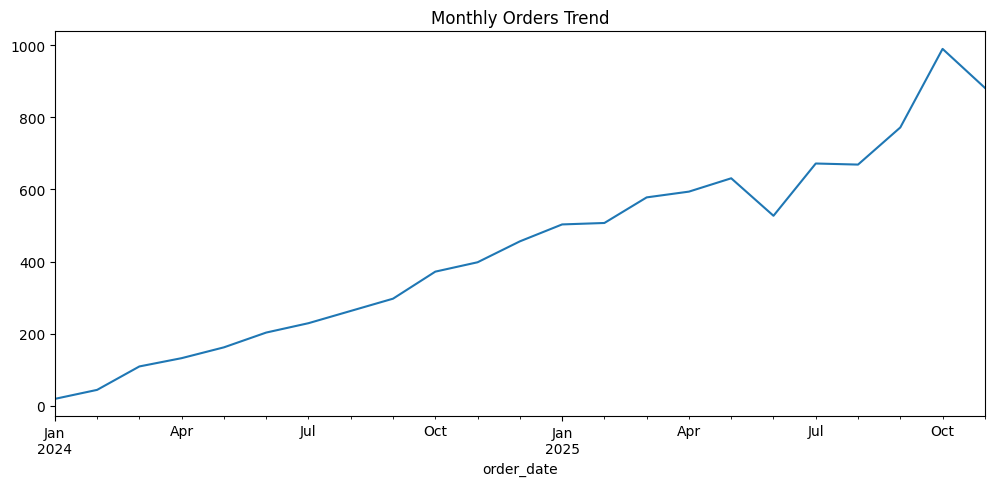

In [24]:
monthly_orders = (
    orders
    .groupby(
        orders["order_date"].dt.to_period("M")
    )
    .size()
)

monthly_orders.plot(
    figsize=(12,5)
)

plt.title("Monthly Orders Trend")
plt.show()

##Support Ticket Analysis

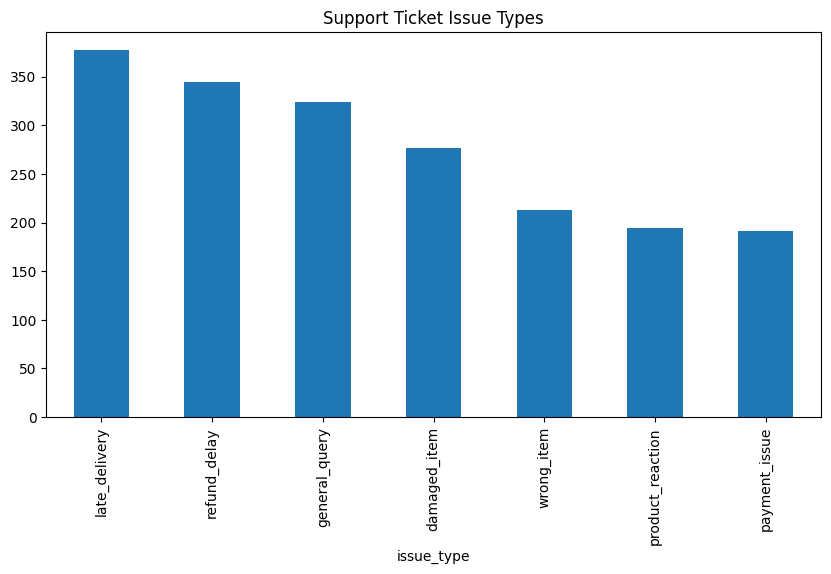

In [25]:
tickets["issue_type"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Support Ticket Issue Types")

plt.show()

## Customer-Level Analysis Dataset

In [26]:
master = (
    snapshot
    .merge(
        churn[["customer_id","churn_next_60d"]],
        on="customer_id",
        how="left",
        suffixes=("","_target")
    )
)

master.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,churn_next_60d_target
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,4,0,0,0,2,0,20,1,train,1
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,31,4,2,3,0,0,0,0,train,0
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,3,0,0,0,0,0,26,1,train,1
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,6,0,0,0,0,0,14,1,train,1
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,95,4,1,1,3,1,9,0,train,0


###Recency vs Churn

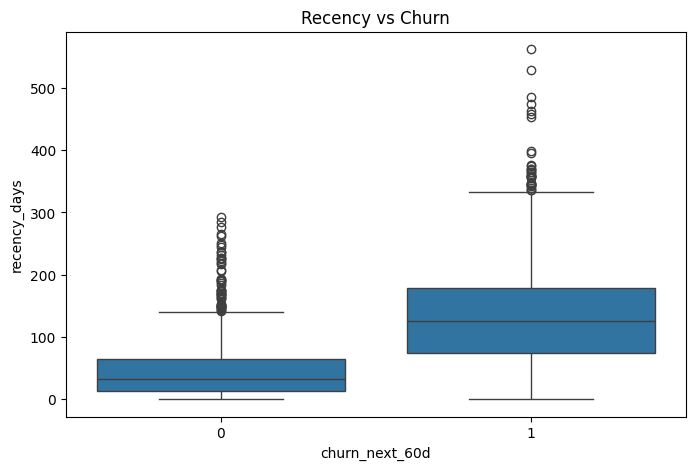

In [34]:
master.groupby(
    "churn_next_60d"
)["recency_days"].mean()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=master,
    x="churn_next_60d",
    y="recency_days"
)

plt.title("Recency vs Churn")
plt.show()

### Hypothesis 1: Inactivity Drives Churn

Customers who churned had an average recency of **135 days**, compared to **45 days** for retained customers.

**Insight:** Longer inactivity is strongly associated with churn.

**Action:** Launch win-back campaigns for customers inactive for 60+ days.

###Frequency vs Churn

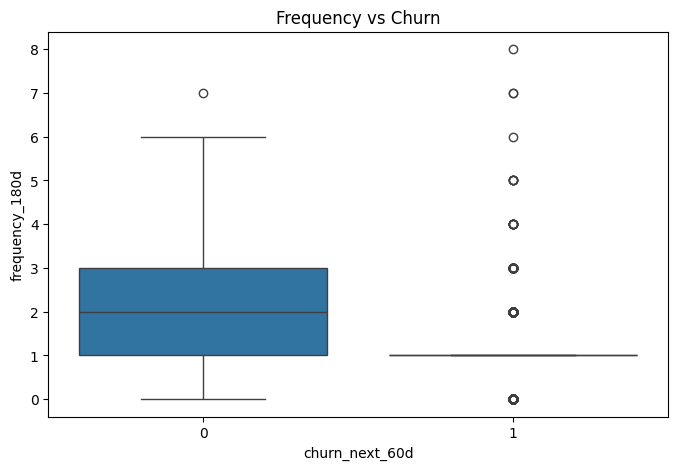

In [35]:
master.groupby(
    "churn_next_60d"
)["frequency_180d"].mean()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=master,
    x="churn_next_60d",
    y="frequency_180d"
)

plt.title("Frequency vs Churn")
plt.show()

### Hypothesis 2: Repeat Purchases Reduce Churn

Retained customers purchased **2.03 times** on average, while churned customers purchased only **1.10 times**.

**Insight:** One-time buyers are more likely to churn.

**Action:** Encourage second and third purchases through targeted offers.

###Monetary vs Churn

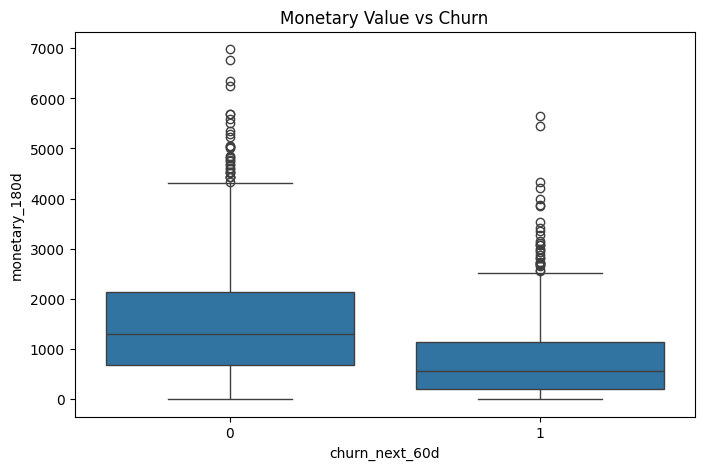

In [36]:
master.groupby(
    "churn_next_60d"
)["monetary_180d"].mean()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=master,
    x="churn_next_60d",
    y="monetary_180d"
)

plt.title("Monetary Value vs Churn")
plt.show()

### Hypothesis 3: Low Spending Increases Churn Risk

Retained customers spent an average of **₹1554.73**, compared to **₹756.22** among churned customers.

**Insight:** Higher-value customers tend to remain loyal.

**Action:** Increase customer lifetime value through bundles and cross-selling.

###Sessions vs Churn

In [30]:
master.groupby(
    "churn_next_60d"
)["sessions_30d"].mean()

,sessions_30d
churn_next_60d,
0,6.732129
1,4.023070


### Hypothesis 4: Low Engagement Predicts Churn

Retained customers averaged **6.73 sessions**, while churned customers averaged **4.02 sessions**.

**Insight:** Lower website/app engagement is linked to higher churn.

**Action:** Re-engage customers showing declining activity.

In [31]:
master.groupby(
    "churn_next_60d"
)["sessions_30d"].mean()

,sessions_30d
churn_next_60d,
0,6.732129
1,4.023070


###Ticket Count vs Churn

In [37]:
master.groupby(
    "churn_next_60d"
)["ticket_count_90d"].mean()

,ticket_count_90d
churn_next_60d,
0,0.296936
1,0.152618


### Hypothesis 5: Support Experience Affects Retention

Support ticket activity differs between churned and retained customers.

**Insight:** Customer support interactions may influence churn behaviour.

**Action:** Monitor unresolved and negative-support cases closely.

###Return Rate vs Churn

In [38]:
master.groupby(
    "churn_next_60d"
)["return_rate_180d"].mean()

,return_rate_180d
churn_next_60d,
0,0.048381
1,0.076328


### Hypothesis 6: High Return Rates May Lead to Churn

Customers with higher return rates appear more likely to churn.

**Insight:** Product dissatisfaction can be an early churn signal.

**Action:** Investigate return reasons and improve customer experience.

###Average Rating vs Churn

In [39]:
master.groupby(
    "churn_next_60d"
)["avg_rating_180d"].mean()

,avg_rating_180d
churn_next_60d,
0,3.910589
1,3.775368


## Key Findings

The strongest churn indicators identified during EDA are:

- High recency (customer inactivity)
- Low purchase frequency
- Low monetary value
- Low digital engagement
- Support experience
- Return behaviour

These factors should be prioritized in future retention campaigns and predictive modeling efforts.

##Churn Distribution

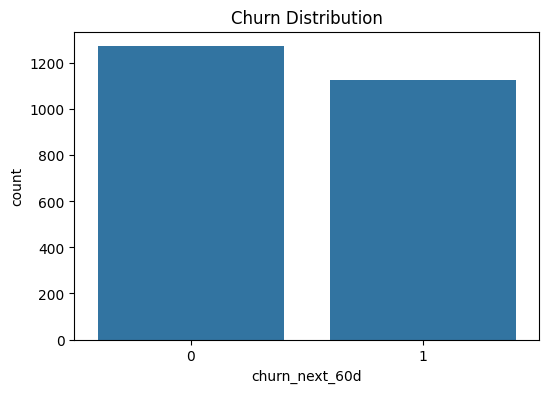

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churn,
    x="churn_next_60d"
)

plt.title("Churn Distribution")
plt.show()

### Observation

The churn dataset appears relatively balanced, making it suitable for predictive modeling without severe class imbalance concerns.

##Acquisition Channel Distribution

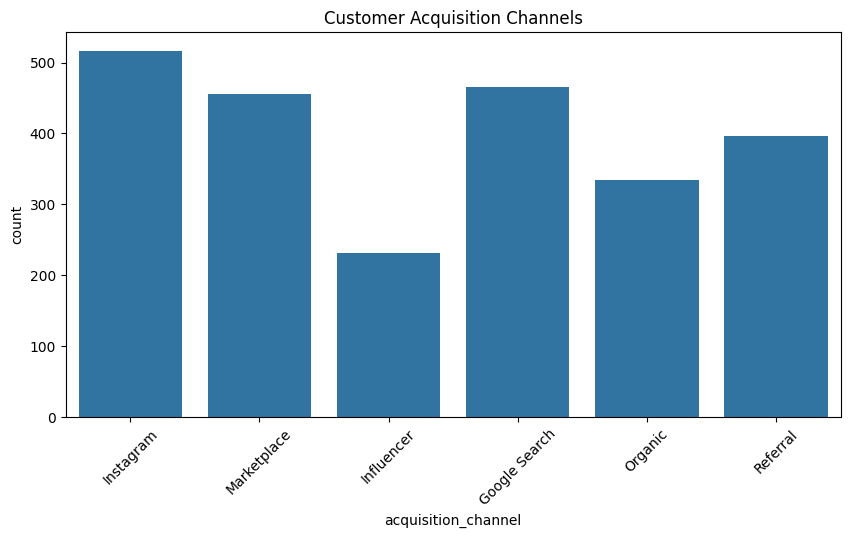

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    x="acquisition_channel"
)

plt.xticks(rotation=45)

plt.title("Customer Acquisition Channels")
plt.show()

### Observation

Customer acquisition is distributed across multiple channels. Future analysis should investigate whether certain acquisition channels have higher churn rates.

##Preferred Category Distribution

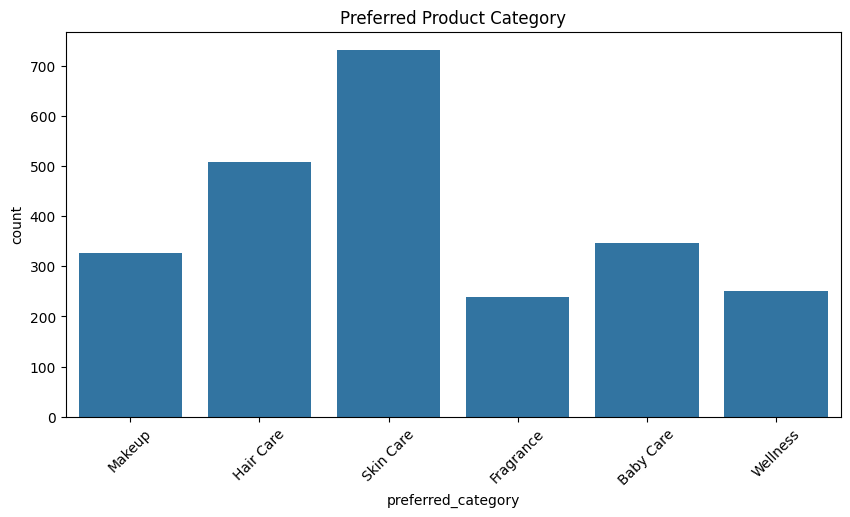

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    x="preferred_category"
)

plt.xticks(rotation=45)

plt.title("Preferred Product Category")
plt.show()

### Observation

Customer preferences vary across product categories. Category-specific retention strategies may be beneficial.

##Ticket Types

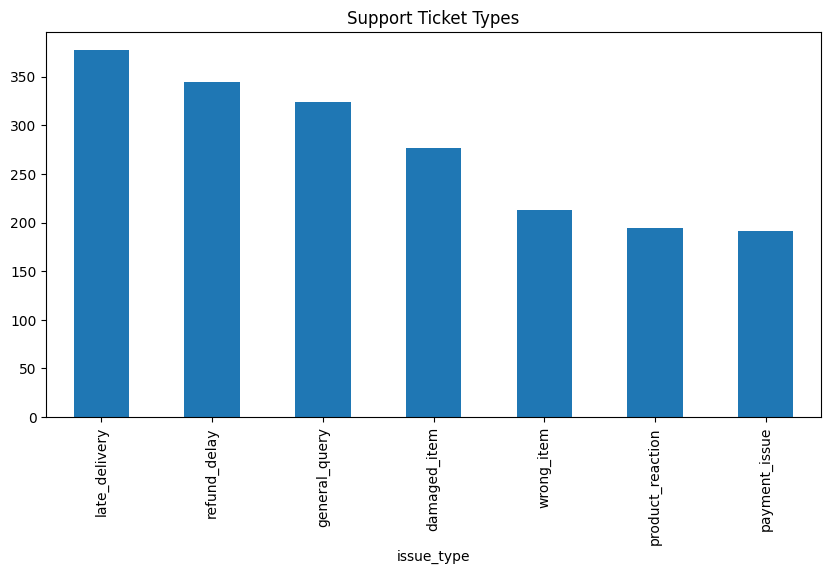

In [43]:
tickets["issue_type"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Support Ticket Types")
plt.show()

### Observation

Support tickets reveal the most common customer issues and highlight potential operational improvement areas.

##Loyalty Tier Distribution

In [44]:
customers["loyalty_tier"] = (
    customers["loyalty_tier"]
    .fillna("Unknown")
)

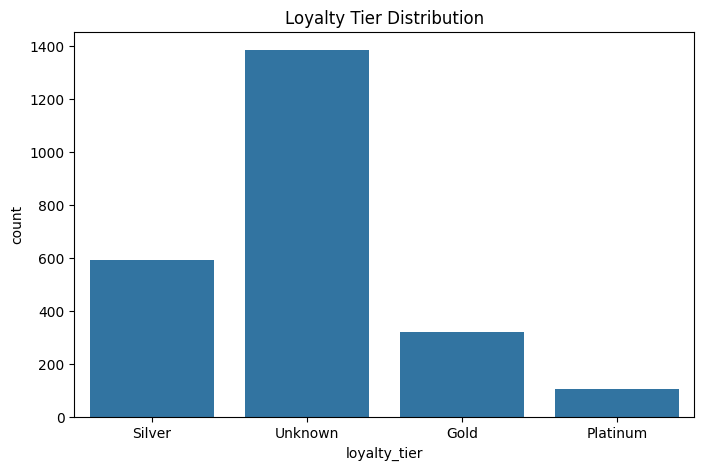

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="loyalty_tier"
)

plt.title("Loyalty Tier Distribution")
plt.show()

### Observation

A large proportion of customers have no recorded loyalty tier, indicating either low program participation or incomplete data capture.

Final EDA Summary

Key findings from the analysis:

- Churned customers remain inactive for significantly longer periods.
- Customers with fewer purchases are more likely to churn.
- Lower-spending customers show higher churn rates.
- Reduced website/app engagement is associated with churn.
- Loyalty and customer engagement appear important for retention.

These findings will guide customer segmentation in Part 2 and feature engineering for churn prediction in Part 3.